In [11]:
import numpy as np
import pandas as pd
from math import *
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib as mpl
from matplotlib import rc
import seaborn as sns
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})

plt.style.use('../src/plot.mplstyle')
mpl.rcParams['figure.dpi'] = 300

cm = 1/2.54

In [12]:
def cycle_colors(n):
    colors = ['#3A86FF','#8338EC', '#FB5607', '#FF006E']
    return colors[n % len(colors)]

In [13]:
df=pd.read_pickle('../data/xyz/df_rev1.pckl.gzip',compression="gzip")
df.head()

,ase_atoms,nb_atoms,size,vol_per_atom,label,nnb,Category_2,Category_color_2,gap_energy,dE_gap,...,mtp_energy,dE_mtp,mtp_at_E_NN,forces,F_max,soap_sim_cSi,atomistic_soap_sim_cSi,PTM,CNA,stein_sim
0,"(Atom('Si', [8.34906, 3.97678, 4.25711], index...",64,1,20.368381,64_atoms/10^10/run_nvt_Si64_2.100_1/npt-anneal...,2.206013,CRN,#332288,-162.973394,0.202696,...,-162.975672,0.185527,"[0.19305147812400492, 0.15265147812402802, 0.1...","[[0.0941393, -0.481743, 0.339763], [-0.277446,...",1.47621,[[0.888628824266952]],"[[0.8212165218831711], [0.9494690544558096], [...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.10197358721811994], [0.111379840462672], [..."
1,"(Atom('Si', [1.85667, 3.22495, 8.08153], index...",64,1,21.216211,64_atoms/10^10/run_nvt_Si64_2.102_1/npt-anneal...,2.236349,CRN,#332288,-162.977760,0.198330,...,-162.983563,0.177636,"[0.23425147812400837, 0.1112514781239895, 0.12...","[[0.352861, -0.442524, -1.15729], [-0.61216, 0...",1.49352,[[0.856601275457118]],"[[0.8101416483448851], [0.816489936573875], [0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.10433139206224115], [0.13074394790877422],..."
2,"(Atom('Si', [6.22054, 5.82036, 11.0988], index...",64,1,21.114870,64_atoms/10^10/run_nvt_Si64_2.104_1/npt-anneal...,2.226015,CRN,#332288,-162.970585,0.205505,...,-162.974297,0.186902,"[0.23565147812402643, 0.14525147812400974, 0.1...","[[-0.00568719, 0.830934, 0.137941], [-0.367886...",1.35239,[[0.8666654436474569]],"[[0.8743297704142471], [0.7685920255720172], [...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.11861841306257677], [0.10605644345182841],..."
3,"(Atom('Si', [2.57367, 5.59541, 5.855], index=0...",64,1,20.662127,64_atoms/10^10/run_nvt_Si64_2.106_1/npt-anneal...,2.208708,CRN,#332288,-163.002762,0.173328,...,-163.002734,0.158464,"[0.10505147812398263, 0.10605147812398741, 0.1...","[[-0.271871, 0.776338, -0.316917], [-0.650419,...",1.41476,[[0.9204173498973871]],"[[0.9744205940318861], [0.9466378517246398], [...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.1375240921990613], [0.13255017470045719], ..."
4,"(Atom('Si', [1.64583, 10.3498, 1.46839], index...",64,1,20.744190,64_atoms/10^10/run_nvt_Si64_2.108_1/npt-anneal...,2.232644,CRN,#332288,-163.003648,0.172442,...,-163.004141,0.157058,"[0.169051478124004, 0.1450514781240031, 0.1472...","[[-0.451078, -0.276074, 0.139343], [-0.808253,...",1.26874,[[0.8991229806499141]],"[[0.8892133998682047], [0.8071166364786589], [...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0.11382671635338178], [0.10688077253984886],..."


In [14]:
# Highlighted structures
para_stru=[2512, 2545, 2561, 2568]
selec_stru=[2491,2576,2604]

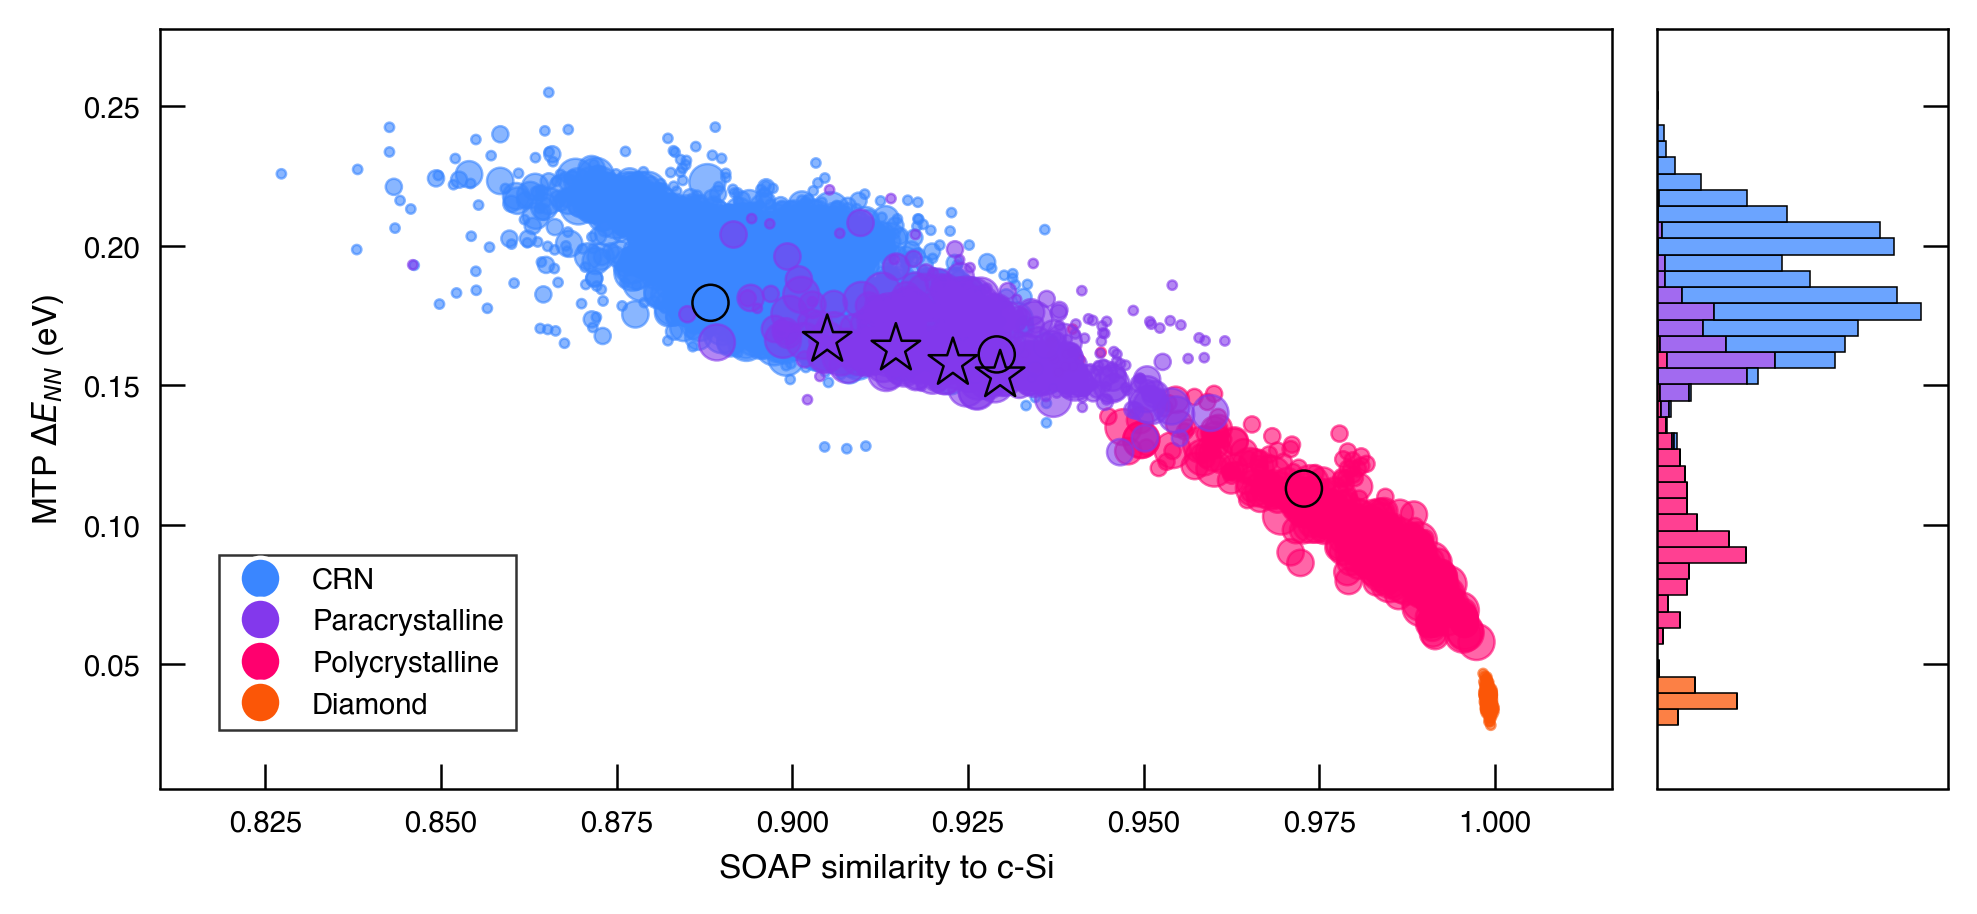

In [15]:
# Plotting Figure 1
fig, axs = plt.subplots(1, 2, figsize=(17*cm, 8*cm), sharey=True, gridspec_kw={'width_ratios': [5,1]})

# LHS plot
ax1 = axs[0]

color_map = {cat: cycle_colors(ii) for ii, cat in enumerate(df["Category_2"].unique())}
df["color"] = df["Category_2"].map(color_map)

category_order = ['Diamond', 'Polycrystalline','CRN', 'Paracrystalline']
for cat in category_order:
    cat_data = df[df["Category_2"] == cat]
    ax1.scatter(cat_data['soap_sim_cSi'], cat_data['dE_mtp'], label=cat, c=cat_data["color"], alpha=0.6, s=cat_data['size']*5)

ax1.set_xlabel('SOAP similarity to c-Si')
ax1.set_ylabel('MTP $\Delta E_{NN}$ (eV)')
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[cat], markersize=10, label=cat) for cat in np.array(('CRN', 'Paracrystalline', 'Polycrystalline', 'Diamond'))]
ax1.legend(handles=legend_elements, loc='lower left')

# Add markers on para_1000 structures
para_1000 = df.iloc[para_stru]
ax1.scatter(para_1000['soap_sim_cSi'], para_1000['dE_mtp'], label='Additional Points', marker='*', s=150, facecolors='none', edgecolors='black')

# Add markers on selec structures
selec_1000 = df.iloc[selec_stru]
ax1.scatter(selec_1000['soap_sim_cSi'], selec_1000['dE_mtp'], label='Additional Points', marker='o', s=75, facecolors='none', edgecolors='black')

# RHS plot
ax2 = axs[1]
g = sns.histplot(data=df, y=df['dE_mtp'], hue=df['Category_2'], multiple="stack", palette=['#3A86FF','#8338EC', '#FB5607', '#FF006E'], stat='count', ax=ax2)
g.get_legend().remove()  # Remove the legend from the right plot

# Share y-axis
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set_xlabel('')
ax2.set_xticklabels('')
ax2.set_xticks([])
plt.tight_layout()
